## Imports

In [ ]:
import pygsdata


# Other libraries we'll need for this tutorial
import numpy as np
from astropy import units as un
from astropy.time import Time
from astropy.coordinates import EarthLocation
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline
from pygsdata.select import select_freqs, select_loads, select_lsts, select_times

# Reading and Writing RHINO Data with `pygsdata`

Now lets read in some example data from RHINO looking at noise-wave calibrators.


Constructing and Integrating a reader for RHINO into the `pygsdata` interface by decorating the reading function with the `gsdata_reader` decorator:

In [12]:
from pygsdata.readers import gsdata_reader
from pygsdata import plots
import h5py

In [5]:
@gsdata_reader(select_on_read=False, formats=['h5df'])
def rhino_raw_reader(
    path: Path,
) -> pygsdata.GSData:
    """ Read in raw RHINOdata to pygsdata.GSData object """
    with h5py.File(path, mode='r') as f:
        data = f['sdr']['sdr_waterfall'][()]
        unix_times = f['sdr']['sdr_times'][()]
        freqs = f['sdr']['sdr_freqs'][()]

        switch_times = f['switches']['switch_times'][()] # out of sync with unix times
        switch_states = f['switches']['switch_states'][()]

        temperatures = f['temperatures']['temperatures'][()]
        temperature_times = f['temperatures']['temperature_times'][()] # out of sync with unix times

        config_grp = f['obs_config']

        aux_sdr_pwr = f['aux_sdr']['aux_sdr_waterfall'][()]
        aux_sdr_times = f['aux_sdr']['aux_sdr_times'][()]

        temp_mask = ~np.isin(temperatures, -273)
        temp_mask = np.array(np.prod(temp_mask, axis=1), dtype=bool)

        temperatures = temperatures[temp_mask] # removes invalid temperatures
        temperature_times = temperature_times[temp_mask]

    telescope = pygsdata.Telescope(
        name = 'RHINO_testing',
        location=EarthLocation.from_geodetic(lon=53.232865*un.deg,
                                             lat=-2.303814*un.deg),
        pols=('xx',),
    )

    auxiliary_measurements = {}

    if not isinstance(aux_sdr_pwr, h5py.Empty):
        cw_power_direct = np.sum(aux_sdr_pwr, axis=1)
        
        cw_power_direct = np.interp(unix_times,
                                    aux_sdr_times,
                                    cw_power_direct) # interpolate CW powers to waterfall times
        auxiliary_measurements['CW_Powers'] = cw_power_direct

    if not isinstance(temperatures, h5py.Empty):
        temperatures = temperatures.T + 273.15
        if temperatures.ndim == 1:
            auxiliary_measurements['Temperatures']  = np.interp(unix_times,
                                                                temperature_times,
                                                                temperatures)
        else:
            for i, temps in enumerate(temperatures):
                auxiliary_measurements[f'Temperatures_{i}'] = np.interp(unix_times,
                                                                temperature_times,
                                                                temps)
        
    
    if not isinstance(switch_states, h5py.Empty):
        switch_states = np.asarray(switch_states)
        switch_times = np.array(switch_times)

        idx = np.searchsorted(switch_times, unix_times, side='right') - 1

        states_array = np.empty(len(unix_times), dtype=switch_states.dtype)

        before_first = idx < 0

        states_array[before_first] = switch_states[0]
        valid = idx >= 0
        states_array[valid] = switch_states[idx[valid]] # creates an array of switch states corresponding to each spectra

        auxiliary_measurements['Switch_States'] = states_array
    
    
    return pygsdata.GSData(
        telescope=telescope,
        data = np.array([[data]]),
        freqs = freqs*un.MHz,
        times = Time(np.array([unix_times]).T, format='unix', scale='utc'),
        auxiliary_measurements = auxiliary_measurements,
        history = pygsdata.History(
            (
                pygsdata.Stamp(
                    "Read from RHINO hd5f file",
                    function="rhino_raw_reader",
                    parameters={"path": path},
                ),
            )
        )
    )


## Lets Try and Read in some raw RHINO data...

#### Download the RHINO data

https://livemanchesterac-my.sharepoint.com/:u:/g/personal/jordan_norris_postgrad_manchester_ac_uk/IQAItnjTZiU2RrkB53xI9xfjAT_DbQ1HdYjekG-e75Di91Q

##### mkdir rhino_data

Move downloaded RHINO to rhino_data directory


In [10]:
raw_rhino_data = rhino_raw_reader(path='2026-01-20_15-00-54_obs.hd5f')

## Inspecting the data

In [20]:
raw_rhino_data.data.shape, raw_rhino_data.data.dtype

((1, 1, 10992, 4096), dtype('float64'))

In [24]:
print("number of times: ", raw_rhino_data.ntimes)
print("number of channels: ", raw_rhino_data.nfreqs)

number of times:  10992
number of channels:  4096


The data output format is:    `(load, pols, times, freqs)`
    

In [22]:
raw_rhino_data.loads

('ant',)

In [25]:
type(raw_rhino_data.times), raw_rhino_data.times.shape

(astropy.time.core.Time, (10992, 1))

In [27]:
raw_rhino_data.times[0].strftime("%Y-%m-%d:%H:%M:%S")

array(['2026-01-20:11:00:53'], dtype='<U19')

In [31]:
raw_rhino_data.lsts, type(raw_rhino_data.lsts), raw_rhino_data.lsts.hourangle, raw_rhino_data.lsts.deg

(<Longitude [[22.55324349],
             [22.55360916],
             [22.55397589],
             ...,
             [ 2.56284543],
             [ 2.56321163],
             [ 2.56357985]] hourangle>,
 astropy.coordinates.angles.core.Longitude,
 array([[22.55324349],
        [22.55360916],
        [22.55397589],
        ...,
        [ 2.56284543],
        [ 2.56321163],
        [ 2.56357985]], shape=(10992, 1)),
 array([[338.29865236],
        [338.30413733],
        [338.30963831],
        ...,
        [ 38.4426815 ],
        [ 38.4481744 ],
        [ 38.4536977 ]], shape=(10992, 1)))

In [36]:
raw_rhino_data.time_ranges.shape, raw_rhino_data.time_ranges[:10,0,:].value

((10992, 1, 2),
 array([[2461060.9589534 , 2461060.95896498],
        [2461060.9589686 , 2461060.95898017],
        [2461060.95898383, 2461060.95899541],
        [2461060.95899893, 2461060.9590105 ],
        [2461060.95901395, 2461060.95902552],
        [2461060.95902923, 2461060.9590408 ],
        [2461060.95904451, 2461060.95905608],
        [2461060.95905959, 2461060.95907117],
        [2461060.95907459, 2461060.95908617],
        [2461060.95908989, 2461060.95910146]]))

In [37]:
raw_rhino_data.freqs

<Quantity [66.       , 66.0019536, 66.0039072, ..., 73.9960928, 73.9980464,
           74.       ] MHz>

In [42]:
print(raw_rhino_data.telescope)

print(raw_rhino_data.telescope.name, raw_rhino_data.telescope.location, raw_rhino_data.telescope.pols)

Telescope(name='RHINO_testing', location=<EarthLocation (3814659.30917241, 5105262.90358448, -254675.30413737) m>, pols=('XX',), integration_time=<Quantity 1. s>, x_orientation=<Angle 0. deg>)
RHINO_testing (3814659.3091724087, 5105262.903584481, -254675.30413736816) m ('XX',)


Note time is saved as (ntimes, nloads)

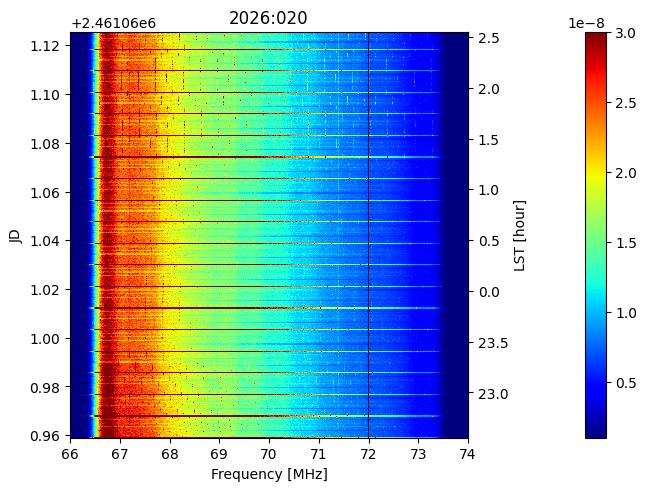

In [13]:
%matplotlib inline
plots.plot_waterfall(raw_rhino_data, **{'cmap':'jet',
                                        'vmin':0.1e-8,
                                        'vmax':3e-8});

In [14]:
raw_rhino_data.auxiliary_measurements

Temperatures_0,Temperatures_1,Switch_States
float64,float64,bytes11
306.97999999999996,293.81365878872896,noise_diode
306.9837133310733,293.847,noise_diode
307.01399999999995,293.847,noise_diode
307.01399999999995,293.83742324004345,noise_diode
307.01399999999995,293.8251355362783,noise_diode
307.02940677922135,293.8315932207786,noise_diode
307.048,293.813,noise_diode
307.0693634731135,293.813,noise_diode
307.082,293.813,noise_diode


In [43]:
print(len(raw_rhino_data.auxiliary_measurements))

10992


In [44]:
raw_rhino_data.effective_integration_time

<Quantity [[[1., 1., 1., ..., 1., 1., 1.]]] s>

## Data Selection

Cutting the data down in frequencies:

In [48]:
print(f"{raw_rhino_data.freqs.min()} -- {raw_rhino_data.freqs.max()}")

66.0 MHz -- 74.0 MHz


In [53]:
cut_data = select_freqs(raw_rhino_data, freq_range=(68*un.MHz, 72*un.MHz))
print(f"{cut_data.freqs.min()} -- {cut_data.freqs.max()}")
print(cut_data.data.shape, cut_data.nfreqs)

68.0004884004884 MHz -- 71.9995115995116 MHz
(1, 1, 10992, 2048) 2048


In [54]:
print(cut_data.history)

2026-03-04T17:23:41.367822
    function: rhino_raw_reader
    message : Read from RHINO hd5f file
    parameters:
        path: 2026-01-20_15-00-54_obs.hd5f
    versions: numpy (2.4.2) | astropy (7.2.0) | pygsdata (0.3.1)
        

2026-03-04T18:27:56.573180
    function: select_freqs
    message : 
    parameters:
        freq_range: (<Quantity 68. MHz>, <Quantity 72. MHz>)
    versions: numpy (2.4.2) | astropy (7.2.0) | pygsdata (0.3.1)
        


And the history has been updated:

In [55]:
keep_idx = np.zeros(cut_data.ntimes, dtype=bool)
keep_idx[::2] = True  # keep every second integration

cut_data = select_times(cut_data, indx=keep_idx)

In [56]:
print(cut_data.ntimes)

5496


In [61]:
cut_data.times[0].strftime("%Y-%m-%d:%H:%M:%S"), cut_data.times[-1].strftime("%Y-%m-%d:%H:%M:%S")

(array(['2026-01-20:11:00:53'], dtype='<U19'),
 array(['2026-01-20:15:00:50'], dtype='<U19'))

In [62]:
cut_data = select_times(cut_data, time_range=(cut_data.times.min(), cut_data.times.min() + 3 * un.minute))

In [64]:
print('ntimes = ', cut_data.ntimes, '\ndata shape =', cut_data.data.shape)
print(cut_data.times[0].strftime("%Y-%m-%d:%H:%M:%S"), cut_data.times[-1].strftime("%Y-%m-%d:%H:%M:%S"))

ntimes =  69 
data shape = (1, 1, 69, 2048)
['2026-01-20:11:00:53'] ['2026-01-20:11:03:51']


#### Now that we have our data in raw format within the GSData object, lets try and seperate out into observing sources.

For this test, we Dicke switched between a load, heated load and the noise-wave calibrators (a long cable with open and shorted terminations as well as just directly open and shorted terminations).

We will calculate the 'uncalibrated radiometric tempereature' $T_{\rm src}^* = T_{\rm NS} \left( \frac{P_{\rm src} - P_{\rm L}}{P_{\rm NS} - P_{\rm L}} \right) + T_{L}$

In [15]:
def create_idx_dict(switch_states, desired_list, dicke_switch_list):
    """ Creates a Dictionary of blocks of indices corresponding to a source """
    source_blocks_indices = {} 
    for cal_source in desired_list:
        source_blocks_indices[cal_source] = [] # set up the cal source dictionary
        for ds in dicke_switch_list:
            source_blocks_indices[f'{cal_source}_{ds}'] = [] # set up dicke switch measurements too
    indices = []
    current_src = 'f'
    for i, swst in enumerate(switch_states):
        # check to see if current source has changed
        if swst != current_src:
            if swst in dicke_switch_list:
                pass
            else:
                current_src = swst # switch the current source
                pass
            pass

        
        if current_src in desired_list: # adds to the next indices sublist is current source is a calibration source
            indices.append(i)
        else:
            pass
        
        if i == len(switch_states)-1: # check if last element
            if swst in dicke_switch_list and current_src in desired_list:
                source_blocks_indices[f'{current_src}_{swst}'].append(indices)
            elif current_src in desired_list:
                source_blocks_indices[current_src].append(indices)
            indices = []

        elif switch_states[i+1] != swst:
            if swst in dicke_switch_list and current_src in desired_list:
                source_blocks_indices[f'{current_src}_{swst}'].append(indices)
            elif current_src in desired_list:
                source_blocks_indices[current_src].append(indices)
            indices = []
        else:
            pass
    return source_blocks_indices

def rolling_median(array,
                   smoothing_idx_length):
    """ Returns the rolling median across a 1d array over some smoothing length """
    x = np.arange(len(array))
    
    smoothed = np.zeros_like(array, dtype=float)

    for i in range(len(x)):
        t0 = x[i] - smoothing_idx_length / 2
        t1 = x[i] + smoothing_idx_length / 2
        in_window = (x >= t0) & (x <= t1)
        smoothed[i] = np.mean(array[in_window]) if np.any(in_window) else array[i]
    return smoothed

def basic_flagger(spectrum,
                  mad_scale=1,
                  smoothing_idx_length=50,
                  reverse_bool = False):
    """ Very basis frequency flagger based on absolute median deviaitons. """
    initial_rolling_median = rolling_median(spectrum,
                                            smoothing_idx_length)


    abs_dev_from_median = np.abs(initial_rolling_median - spectrum)
    dev_rolling_median = rolling_median(abs_dev_from_median,
                                        smoothing_idx_length)
    
    flags = np.where(abs_dev_from_median > dev_rolling_median*mad_scale, False, True)

    if reverse_bool: flags = ~flags

    return flags


def uncal_temp_avg_and_flags(full_waterfall:np.ndarray,
                             load_temperatures:np.ndarray,
                             ns_temperatures:np.ndarray,
                             spectra_times:np.ndarray,
                             source_idx_dict:dict,
                             cycle_idx: int,
                             source: str,
                             switch_buffer=3):
    source_idx = source_idx_dict[source][cycle_idx]
    source_idx = source_idx[switch_buffer:-switch_buffer]
    load_idx = source_idx_dict[f'{source}_load'][cycle_idx]
    load_idx = load_idx[switch_buffer:-switch_buffer]
    ns_idx = source_idx_dict[f'{source}_heated_load'][cycle_idx]
    ns_idx = ns_idx[switch_buffer:-switch_buffer]

    p_src = np.mean(full_waterfall[source_idx], axis=0) # get mean of waterfall
    p_src_nsamps = np.ones_like(p_src) * len(full_waterfall[source_idx]) # get nsamps in p_src

    p_l = np.mean(full_waterfall[load_idx], axis=0)
    p_l_samps = np.ones_like(p_l) * len(full_waterfall[load_idx])

    p_ns = np.mean(full_waterfall[ns_idx], axis=0)
    p_ns_samps = np.ones_like(p_ns) * len(full_waterfall[ns_idx])

    t_ns = np.mean(ns_temperatures[ns_idx])
    t_l = np.mean(load_temperatures[load_idx])

    q = (p_src - p_l) / (p_ns - p_l)

    # uncal_temp
    t_star_source = ((t_ns - t_l) * q) + t_l

    t_star_source_flags = basic_flagger(t_star_source,
                                        reverse_bool=True)

    n_samps = p_src_nsamps + p_l_samps + p_ns_samps

    time = np.median(spectra_times[source_idx])

    return t_star_source, t_star_source_flags, n_samps, time




In [18]:
def convert_raw_to_uncalibrated_temp(
        data:pygsdata.GSData,
        dicke_cal_labels:list=['load','heated_load']
) -> pygsdata.GSData:
    data = pygsdata.select_freqs(data, freq_range=(67*un.MHz, 73*un.MHz))
    ns_temperatures = np.array(data.auxiliary_measurements['Temperatures_0'])
    load_temperatures = np.array(data.auxiliary_measurements['Temperatures_1'])
    switch_states = list(data.auxiliary_measurements['Switch_States'])
    
    loads = list(set(switch_states))
    for l in dicke_cal_labels: loads.remove(l)

    switch_states = np.asarray(switch_states)
    #Create a source and l, ns dictionary for seperation and averaging
    source_idx_dict = create_idx_dict(switch_states,
                                      desired_list=loads,
                                      dicke_switch_list=dicke_cal_labels)
    
    # calculate number of full source cycles
    full_cycles = np.inf
    for _, k in source_idx_dict.items():
        if len(k) < full_cycles: full_cycles = len(k) 

    new_data_array = np.empty(shape=(len(loads), # loads
                                     1, # pols
                                     full_cycles, # times
                                     len(data.freqs))) # freqs
    
    nsamps = np.empty(shape=(len(loads),
                                     1,
                                     full_cycles,
                                     len(data.freqs)))
    
    flags = np.empty(shape=(len(loads),
                            1,
                            full_cycles,
                            len(data.freqs)))
    
    times_array = np.empty(shape=(full_cycles,
                                  len(loads)),
                                  dtype=Time)
    
    for i, l in enumerate(loads):
        for j in range(full_cycles):
            t_src_vec, t_src_flags, nsamps_src, t = uncal_temp_avg_and_flags(full_waterfall=data.data[0,0],
                                                                             load_temperatures=load_temperatures,
                                                                             ns_temperatures=ns_temperatures,
                                                                             spectra_times=data.times.T[0].unix,
                                                                             source_idx_dict=source_idx_dict,
                                                                             cycle_idx=j,
                                                                             source=l)
            new_data_array[i, 0, j, :] = t_src_vec
            nsamps[i, 0, j, :] = nsamps_src
            flags[i, 0, j, :] = t_src_flags
            times_array[j,i] = t
    times_array = times_array.astype(np.float64)
    time_obj_array = Time(times_array, format='unix', scale='utc')

    flags = pygsdata.GSFlag(flags)

    return pygsdata.GSData(telescope=data.telescope,
                           data=new_data_array,
                           freqs=data.freqs,
                           times=time_obj_array,
                           pols=data.pols,
                           loads=loads,
                           nsamples=nsamps,
                           data_unit='uncalibrated_temp',
                           flags={'T_src_flagger':flags})




uncal_temp_rhino = convert_raw_to_uncalibrated_temp(raw_rhino_data)

#### Plot the loads



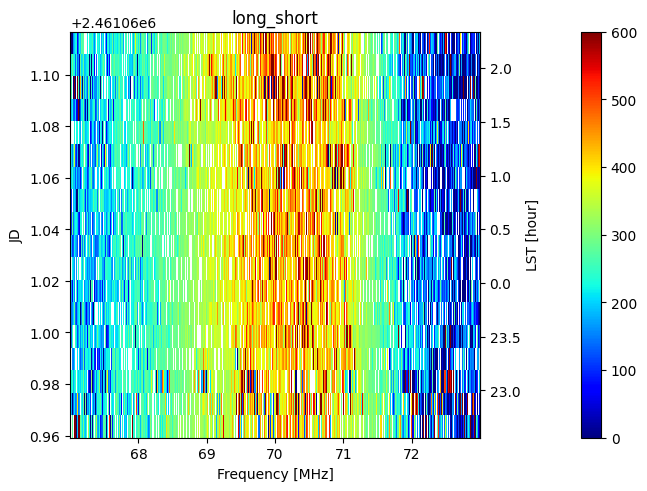

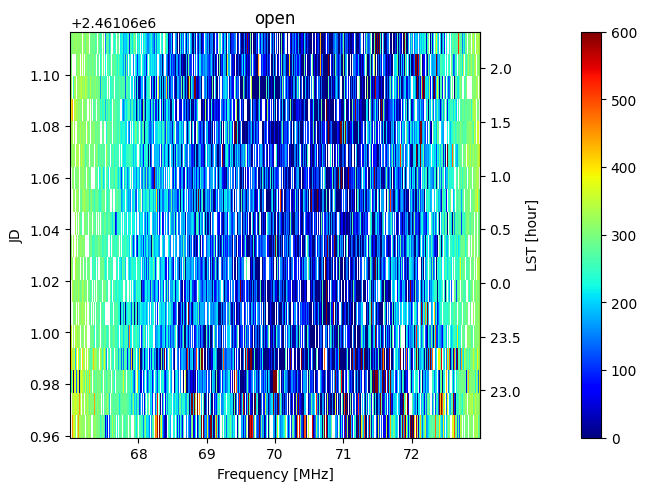

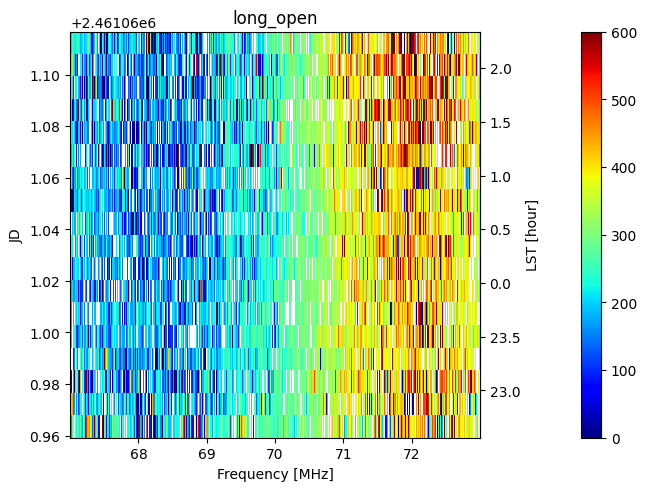

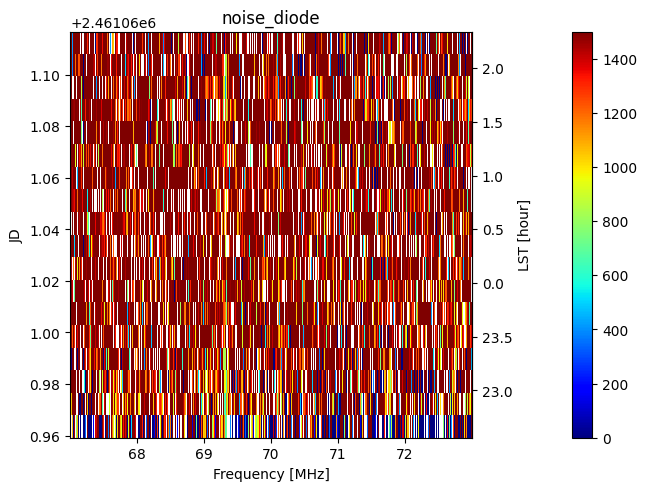

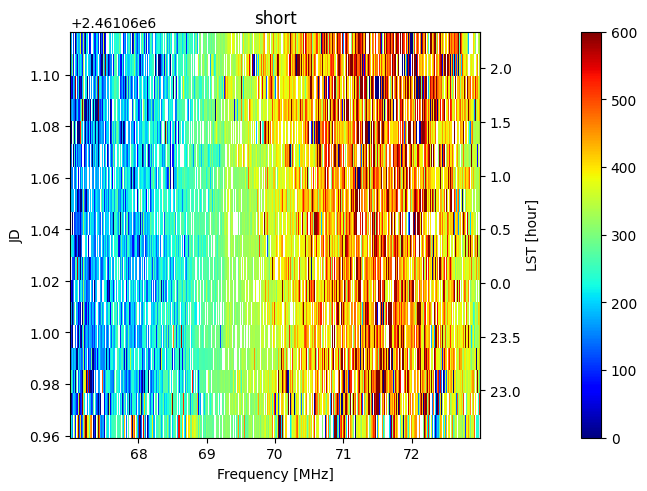

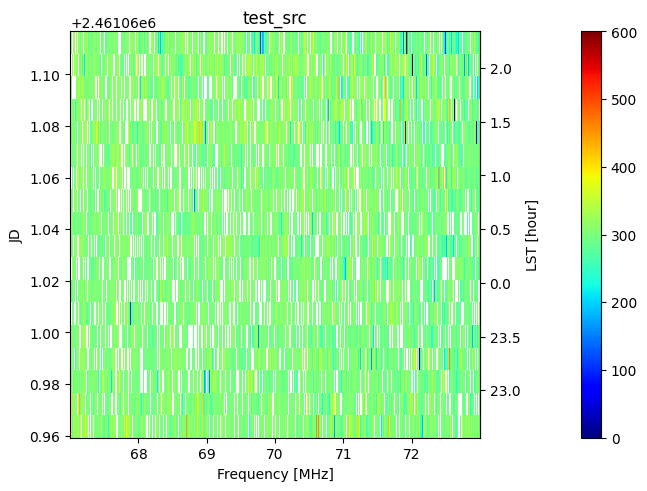

In [19]:
for i, load in enumerate(uncal_temp_rhino.loads):
    if load == 'noise_diode':
        plots.plot_waterfall(uncal_temp_rhino,
                            load=i,
                            title=load, **{"vmin":0, "vmax":1500, 'cmap':'jet'})
    else:
        plots.plot_waterfall(uncal_temp_rhino,
                            load=i,
                            title=load, **{"vmin":0, "vmax":600,'cmap':'jet'} )


## Data Iteration

As we said, the actual data array is four-dimensional. Often you want to iterate over a certain dimension, but it's annoying to have to remember which axis that is. `pygsdata` provides some handy named iterators:

In [43]:
for raw_idx, array_idx in enumerate(data.load_iter()):
    print(data.loads[raw_idx], data.data[array_idx].shape)

ant (1, 2257, 32768)
internal_load (1, 2257, 32768)
internal_load_plus_noise_source (1, 2257, 32768)


In [44]:
for i, freq_idx in enumerate(data.freq_iter()):
    print(i, data.data[freq_idx].shape)
    if i > 3:
        break

0 (3, 1, 2257)
1 (3, 1, 2257)
2 (3, 1, 2257)
3 (3, 1, 2257)
4 (3, 1, 2257)


In [45]:
for i, time_idx in enumerate(data.time_iter()):
    print(i, data.data[time_idx].shape)
    if i > 3:
        break

0 (3, 1, 32768)
1 (3, 1, 32768)
2 (3, 1, 32768)
3 (3, 1, 32768)
4 (3, 1, 32768)
